# From k value to Gardner via HYPAGS + Curve Fitting Routine

*Martin Vonk (2025)*

## Overview

This notebook demonstrates an integrated workflow that combines parameter estimation techniques:

1. **HYPAGS estimation** - Get initial van Genuchten parameters from a single saturated conductivity measurement
2. **Data generation** - Create water retention and conductivity data from the estimated model
3. **Curve fitting** - Fit a different soil model (Gardner) to this data using least-squares optimization

This workflow is useful for:
- **Model conversion** - Converting between different soil model formulations (van Genuchten → Gardner, etc.)
- **Hypothesis testing** - Comparing how well different models fit the same data
- **Parameter refinement** - Using HYPAGS as an initial guess, then refining with additional data
- **Workflow demonstration** - Showing how `pedon` components integrate together

## Workflow Steps

This notebook follows these steps:
1. Import libraries and define helper plotting functions
2. Estimate van Genuchten parameters using HYPAGS from a k value
3. Generate synthetic water retention and conductivity data from the van Genuchten model
4. Set up and visualize initial Gardner model parameters
5. Fit the Gardner model to the synthetic data
6. Compare the fitted Gardner model with the original van Genuchten curve

## Setup

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pedon as pe

# pe.show_versions()

### Helper plot

In [2]:
def plot_compare(
    soilsample: pe.SoilSample, soilmodel: pe.SoilModel
) -> np.typing.NDArray[plt.Axes]:
    """Plot the soil water retention curve (SWRC) and hydraulic conductivity function (HCF) for a given soil sample and fitted soil model."""
    f, ax = plt.subplots(1, 2, sharey=True, figsize=(7.0, 6.0))
    ax[0].scatter(soilsample.theta, soilsample.h, c="k", s=10, label="Soil Sample")
    _ = pe.plot.swrc(
        soilmodel, ax=ax[0], label=f"Soil Model {soilmodel.__class__.__name__}"
    )
    ax[0].set_yscale("log")
    ax[0].set_xlim(0, 0.5)
    ax[0].set_yticks(soilsample.h)
    ax[0].set_xticks(np.linspace(0, 0.5, 6))
    ax[0].set_ylim(min(soilsample.h), max(soilsample.h))
    ax[1].scatter(soilsample.k, soilsample.h, c="k", s=10)
    _ = pe.soilmodel.plot_hcf(soilmodel, ax=ax[1])

    ax[1].set_yscale("log")
    ax[1].set_xscale("log")

    k_left = 10 ** (np.floor(np.log10(min(soilsample.k))) - 1)
    k_right = 10 ** (np.ceil(np.log10(max(soilsample.k))) + 1)
    ax[1].set_xlim(k_left, k_right)
    ax[0].set_ylabel(r"|$\psi$| [cm]")
    ax[0].set_xlabel(r"$\theta$ [-]")
    ax[1].set_xlabel(r"$K_s$ [cm/d]")
    ncol = 3
    ax[0].legend(
        loc=(-0.02, 1),
        fontsize=6,
        frameon=False,
        ncol=ncol,
        columnspacing=0.8,
        handlelength=2.5,
    )

    f.align_xlabels()
    return ax

## Step 1: Estimate van Genuchten Parameters via HYPAGS

We start with a single measurement: saturated hydraulic conductivity of 100 cm/d (typical for sandy soil). HYPAGS will estimate the complete van Genuchten parameter set from this single value.

Note: HYPAGS expects k in m/s, so we convert from cm/d.

In [3]:
k_cmd = 100.0  # cm/d
k_ms = k_cmd / 86400 / 100  # m/s since HYPAGS expects that
genuchten = pe.SoilSample(k=np.array([k_ms])).hypags()
genuchten.k_s = k_cmd  # convert back to cm/d
genuchten

Genuchten(k_s=100.0, theta_r=0.108, theta_s=np.float64(0.260064701261806), alpha=np.float64(3.2905002387762474), n=np.float64(1.7228201552429758), l=0.5)

## Step 2: Convert to Gardner Model via Curve Fitting

Now we'll fit a Gardner model to the van Genuchten data. This demonstrates model conversion: taking one model's predictions and fitting a different model to match them.

### Why This Workflow?

Sometimes you need to convert between models because:
- Your simulation software only accepts a specific model
- You want to compare model performance on the same data
- You're testing whether a simpler model (like Gardner) works as well as a more complex one (like van Genuchten)

### Sample Pressure Heads

We create synthetic data by evaluating the van Genuchten model at various pressure head values. Note the careful range selection to avoid numerical issues where conductivity becomes extremely small.

### Sample Genuchten curve for data points

In [4]:
h = np.logspace(
    -3, 2, 100
)  # carefull with sampling h since k goes to zero very fast for large h which gives trouble with logs
k = genuchten.k(h)
theta = genuchten.theta(h)
soilsample = pe.SoilSample(h=h, k=k, theta=theta)

### Setting Parameter Bounds

Before fitting, we define reasonable bounds for each Gardner parameter. The bounds have three values:
- **p_ini**: Initial guess for the optimizer
- **p_min**: Minimum allowed value
- **p_max**: Maximum allowed value

Good bounds are crucial for successful fitting - they guide the optimization and prevent unrealistic values.

In [5]:
pbounds = pe.get_params("Gardner")
pbounds.loc["k_s"] = [k_cmd, k_cmd - 100.0, k_cmd + 10.0]
pbounds.loc["theta_s"] = [genuchten.theta_s, 0.2, 0.3]
pbounds.loc["c"] = [0.15, 0.0001, 0.5]
pbounds.loc["m"] = [0.3, 0.0001, 0.5]
pbounds

No default parameter bounds for SoilModel type Gardner


,p_ini,p_min,p_max
k_s,100.000000,0.0000,110.0
theta_s,0.260065,0.2000,0.3
m,0.300000,0.0001,0.5
c,0.150000,0.0001,0.5


#### Visualize Initial Fit

Let's see how the initial Gardner model parameters compare with the van Genuchten data. These plots show the data points (black dots) and the initial Gardner model curve. The fit will likely be poor at this stage.

AttributeError: module 'pedon.soilmodel' has no attribute 'plot_hcf'

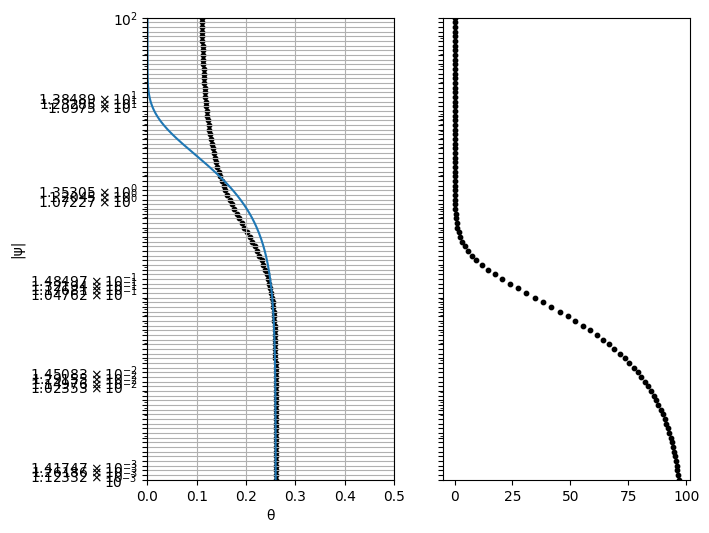

In [6]:
# compare initial guesses with genuchten
gardner_ini = pe.Gardner(**pbounds["p_ini"].to_dict())
axes = plot_compare(soilsample, gardner_ini)
axes[0].set_ylim(h[0], h[-1])

### Perform the Curve Fitting

Now we use the least-squares algorithm to optimize Gardner parameters. The `W1` parameter controls how we weight the hydraulic conductivity data relative to water content data. A value of 0.1 means we weight conductivity less heavily than water content, which is common practice because conductivity data tends to be noisier and covers a wider range.

In [ ]:
gardner = soilsample.fit(
    pe.Gardner,
    pbounds=pbounds,
    # k_s=k_cmd,  # fix option to fix k_s and only fit k_r
    W1=0.1,  # how to weight k vs theta data
)
gardner

Gardner(k_s=np.float64(1.7140071030290098), theta_s=np.float64(0.22527115097409922), m=np.float64(0.025716662197584478), c=np.float64(0.30552460435612094))

## Results and Interpretation

The plots above show the fitted Gardner model (curves) and the original van Genuchten data (points). 


(np.float64(0.001), np.float64(100.0))

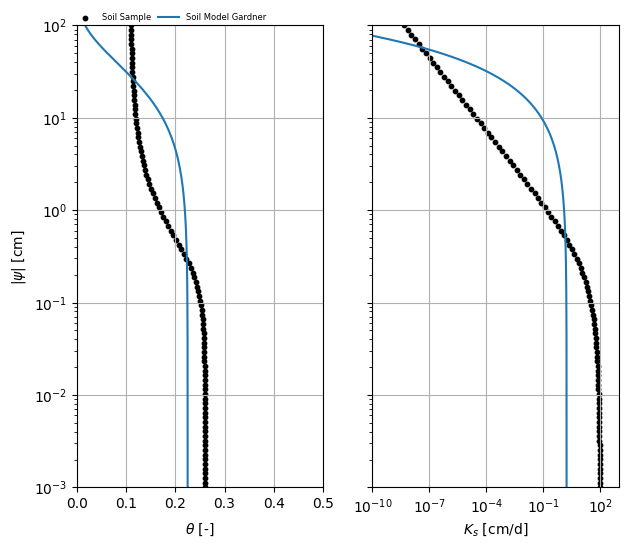

In [ ]:
# compare initial guesses with genuchten
axes = plot_compare(soilsample, gardner)
axes[0].set_ylim(h[0], h[-1])